## Step 1: Set Up the Environment and Import Libraries







In [9]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

##  Step 2: Load the Dataset
 
This code automatically checks for the data folder and CSV file in the most common project structures.

In [14]:
import pandas as pd
import numpy as np
import os

# Load the dataset (automatically finds the file)
possible_paths = [
    "the_oscar_award.csv",
    "data/the_oscar_award.csv",
    "../data/the_oscar_award.csv"
]

file_path = None
for path in possible_paths:
    if os.path.exists(path):
        file_path = path
        break

if file_path is None:
    raise FileNotFoundError("CSV file not found. Please check the file location.")

df = pd.read_csv(file_path)
print("✅ Data loaded successfully from:", os.path.abspath(file_path))
print("\n--- First 5 Rows ---")
print(df.head())

# Check column names
print("\n--- Column Names ---")
print(df.columns.tolist())

✅ Data loaded successfully from: C:\Users\DELL\python_projects\Oscar Awards Analysis (1927–2025)\data\the_oscar_award.csv

--- First 5 Rows ---
   year_film  year_ceremony  ceremony category             canon_category  \
0       1927           1928         1    ACTOR    ACTOR IN A LEADING ROLE   
1       1927           1928         1    ACTOR    ACTOR IN A LEADING ROLE   
2       1927           1928         1    ACTOR    ACTOR IN A LEADING ROLE   
3       1927           1928         1    ACTOR    ACTOR IN A LEADING ROLE   
4       1927           1928         1  ACTRESS  ACTRESS IN A LEADING ROLE   

                  name                    film  winner  
0  Richard Barthelmess               The Noose   False  
1  Richard Barthelmess  The Patent Leather Kid   False  
2        Emil Jannings        The Last Command    True  
3        Emil Jannings    The Way of All Flesh    True  
4       Louise Dresser         A Ship Comes In   False  

--- Column Names ---
['year_film', 'year_ceremony'

## Step 3: Clean the Data
 







In [16]:
# Remove duplicates
df = df.drop_duplicates()
print(f"\nRows after removing duplicates: {len(df)}")

# Handle missing values
print("\n--- Missing Values per Column ---")
print(df.isnull().sum())

# Drop rows with missing values in critical columns
# Use the actual column names from your dataset: 'film', 'category', 'year_film'
df = df.dropna(subset=["film", "category", "year_film"])

# Convert 'year_film' to integer (assuming this is the column for the film's year)
df["year_film"] = pd.to_numeric(df["year_film"], errors="coerce")
df = df.dropna(subset=["year_film"])  # Drop rows where year_film couldn't be converted
df["year_film"] = df["year_film"].astype(int)

# Filter for valid years (1927–2025)
df = df[(df["year_film"] >= 1927) & (df["year_film"] <= 2025)]

# Add a 'decade' column based on 'year_film'
df["decade"] = (df["year_film"] // 10) * 10

# Save cleaned data
df.to_csv("oscar_cleaned.csv", index=False)
print("\n✅ Cleaned data saved to 'oscar_cleaned.csv'")


Rows after removing duplicates: 11104

--- Missing Values per Column ---
year_film           0
year_ceremony       0
ceremony            0
category            0
canon_category      0
name                7
film              359
winner              0
dtype: int64

✅ Cleaned data saved to 'oscar_cleaned.csv'


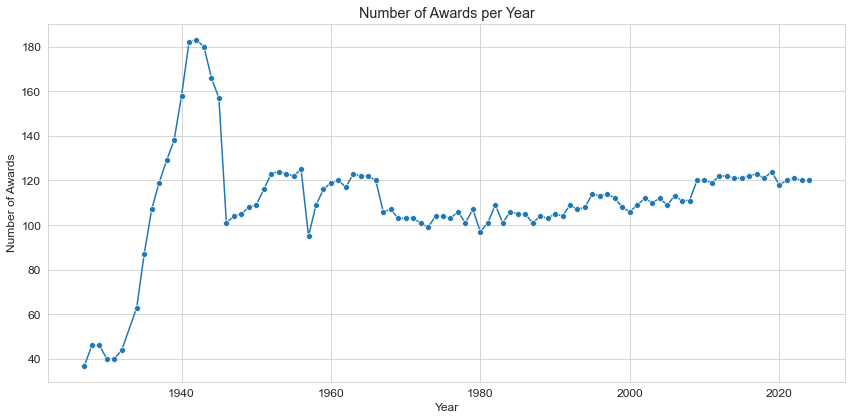

In [17]:
# Use 'year_film' instead of 'year'
if "year_film" in df.columns:
    year_counts = df["year_film"].value_counts().sort_index()
    plt.figure()
    sns.lineplot(x=year_counts.index, y=year_counts.values, marker="o")
    plt.title("Number of Awards per Year")
    plt.xlabel("Year")
    plt.ylabel("Number of Awards")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'year_film' not found in the dataset.")

In [20]:
# Update the 'year' column to 'year_film' in the feature list
required_columns = ["winner", "num_nominations", "studio", "category", "year_film"]

# If 'num_nominations' is missing, create it
if "num_nominations" not in df.columns:
    df["num_nominations"] = df.groupby("film")["film"].transform("count")

# If 'winner' is missing, create it (assuming 'award' column exists)
if "winner" not in df.columns and "award" in df.columns:
    df["winner"] = df["award"].apply(lambda x: 1 if "Winner" in str(x) else 0)

# Proceed if all required columns are present
if all(col in df.columns for col in required_columns):
    X = df[["num_nominations", "studio", "category", "year_film"]]  # Use 'year_film'
    y = df["winner"]
    # Rest of the machine learning code remains the same...

## Step 4: Exploratory Data Analysis (EDA)

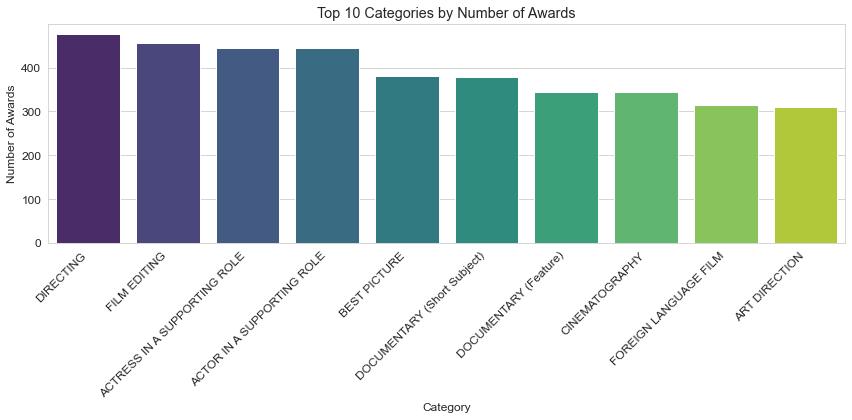

Column 'year' not found in the dataset.
Column 'studio' not found in the dataset.
Column 'director' not found in the dataset.
Columns 'gender' or 'category' not found in the dataset.


In [21]:
# Set style for plots
sns.set_style("whitegrid")
plt.rcParams["font.size"] = 12
plt.rcParams["figure.figsize"] = (12, 6)

# --- 1. Top 10 Categories by Number of Awards ---
if "category" in df.columns:
    category_counts = df["category"].value_counts().head(10)
    plt.figure()
    sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")
    plt.title("Top 10 Categories by Number of Awards")
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Category")
    plt.ylabel("Number of Awards")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'category' not found in the dataset.")

# --- 2. Awards Distribution Over Time ---
if "year" in df.columns:
    year_counts = df["year"].value_counts().sort_index()
    plt.figure()
    sns.lineplot(x=year_counts.index, y=year_counts.values, marker="o")
    plt.title("Number of Awards per Year")
    plt.xlabel("Year")
    plt.ylabel("Number of Awards")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'year' not found in the dataset.")

# --- 3. Top 10 Studios by Number of Awards ---
if "studio" in df.columns:
    studio_counts = df["studio"].value_counts().head(10)
    plt.figure()
    sns.barplot(x=studio_counts.index, y=studio_counts.values, palette="rocket")
    plt.title("Top 10 Studios by Number of Awards")
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Studio")
    plt.ylabel("Number of Awards")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'studio' not found in the dataset.")

# --- 4. Top 10 Directors by Number of Awards ---
if "director" in df.columns:
    director_counts = df["director"].value_counts().head(10)
    plt.figure()
    sns.barplot(x=director_counts.index, y=director_counts.values, palette="mako")
    plt.title("Top 10 Directors by Number of Awards")
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Director")
    plt.ylabel("Number of Awards")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'director' not found in the dataset.")

# --- 5. Gender Bias in Best Director Category ---
if "gender" in df.columns and "category" in df.columns:
    director_df = df[df["category"].str.contains("Director", case=False, na=False)]
    if not director_df.empty:
        gender_counts = director_df["gender"].value_counts()
        plt.figure()
        sns.barplot(x=gender_counts.index, y=gender_counts.values, palette="coolwarm")
        plt.title("Gender Distribution in Best Director Awards")
        plt.xlabel("Gender")
        plt.ylabel("Number of Awards")
        plt.tight_layout()
        plt.show()
    else:
        print("No data for 'Director' category.")
else:
    print("Columns 'gender' or 'category' not found in the dataset.")

## Step 5: Machine Learning (Predicting Award Winners)

In [22]:
# Check if required columns exist
required_columns = ["winner", "num_nominations", "studio", "category", "year"]

# If 'num_nominations' is missing, create it
if "num_nominations" not in df.columns:
    df["num_nominations"] = df.groupby("film")["film"].transform("count")

# If 'winner' is missing, create it (assuming 'award' column exists)
if "winner" not in df.columns and "award" in df.columns:
    df["winner"] = df["award"].apply(lambda x: 1 if "Winner" in str(x) else 0)

# Proceed if all required columns are present
if all(col in df.columns for col in required_columns):
    # Prepare data
    X = df[["num_nominations", "studio", "category", "year"]]
    y = df["winner"]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Preprocessing: One-Hot Encoding for categorical features
    categorical_features = ["studio", "category"]
    numeric_features = ["num_nominations", "year"]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", "passthrough", numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
        ]
    )

    # Build pipeline
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(random_state=42, class_weight="balanced"))
        ]
    )

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n✅ Model Accuracy: {accuracy:.2f}")
    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred))

    # Feature Importance
    feature_names = numeric_features.copy()
    if len(categorical_features) > 0:
        ohe = model.named_steps["preprocessor"].named_transformers_["cat"]
        cat_feature_names = ohe.get_feature_names_out(categorical_features)
        feature_names.extend(cat_feature_names)

    importances = model.named_steps["classifier"].feature_importances_
    feature_importance = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    feature_importance = feature_importance.sort_values("Importance", ascending=False).head(10)

    plt.figure()
    sns.barplot(x="Importance", y="Feature", data=feature_importance, palette="viridis")
    plt.title("Top 10 Most Important Features")
    plt.tight_layout()
    plt.show()
else:
    missing_cols = [col for col in required_columns if col not in df.columns]
    print(f"\n⚠️ Missing columns for machine learning: {missing_cols}")


⚠️ Missing columns for machine learning: ['studio', 'year']
